### Importing necessary libraries

In [1]:
# !pip install torchmetrics

In [2]:
# importing necessary libraries 
import torch 
from torch import nn 
import torchvision 

import matplotlib.pyplot as plt 

from torchvision import datasets
from torchvision.transforms import ToTensor
from torchmetrics import Accuracy

# check version 
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")


PyTorch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128


### Getting the dataset FashionMNIST 

In [3]:
# getting the dataset FashionMNIST 
train_data = datasets.FashionMNIST(
    root = 'data', 
    train = True, 
    download = True, 
    transform = ToTensor(),
    target_transform = None 
)

test_data = datasets.FashionMNIST(
    root = 'data', 
    train = False, 
    transform = ToTensor()
)


In [4]:
# see the first training sample 
image, label = train_data[0]
print(label, image)

9 tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.000

In [5]:
# lets see image shape
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [6]:
# classes name 
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [7]:
# classes name and their index number 
class_names_idx = train_data.class_to_idx
class_names_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

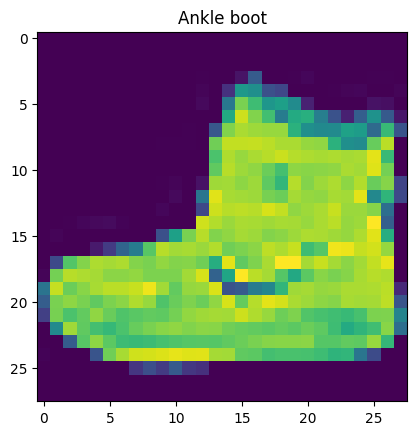

In [8]:
# visualize 
image, label = train_data[0]
plt.imshow(image.reshape(28,28))
plt.title(class_names[label])
plt.show()

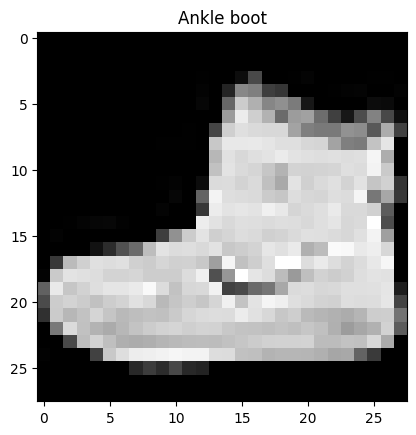

In [9]:
image, label = train_data[0]
plt.imshow(image.reshape(28,28), cmap='gray')
plt.title(class_names[label])
plt.show()

In [10]:
torch.randint(0, len(train_data), size=[1])

tensor([46237])

In [11]:
torch.randint(0, len(train_data), size=[1]).item()

47087

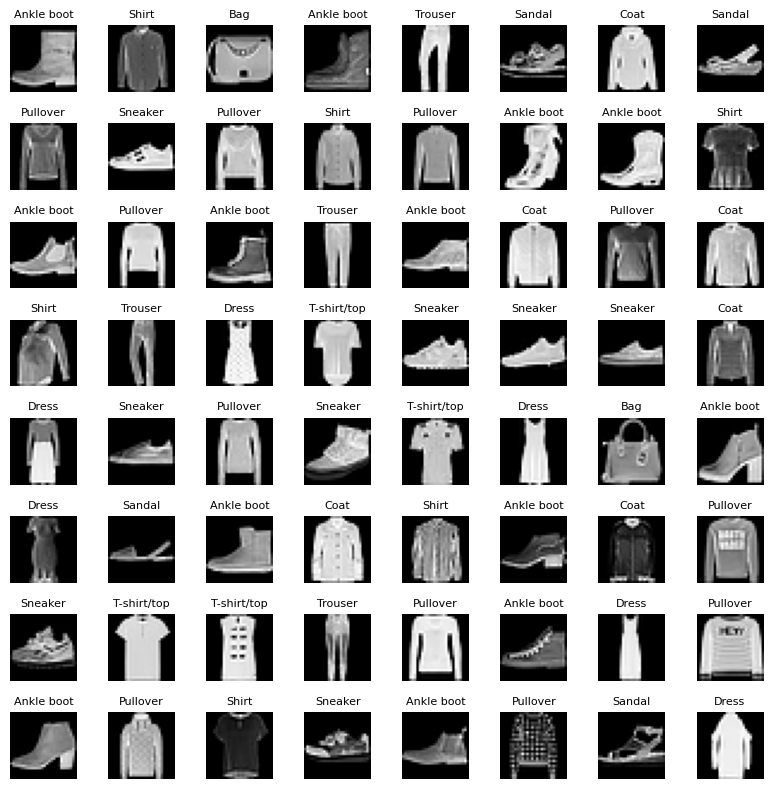

In [12]:
torch.manual_seed(42)

fig, axes = plt.subplots(8,8, figsize=(8,8))

for ax in axes.flat:
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    image, label = train_data[random_idx]

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(class_names[label], fontsize=8)
    ax.axis("off")

plt.tight_layout()

### Prepare DataLoader 

In [13]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
# train data 
train_dataloader = DataLoader(train_data, 
                              batch_size=BATCH_SIZE, 
                              shuffle=True)

# test data 
test_dataloader = DataLoader(test_data, 
                              batch_size=BATCH_SIZE, 
                              shuffle=False)

In [14]:
print(f"Number of sample is : {len(train_dataloader)} and batch size is 32")

Number of sample is : 1875 and batch size is 32


In [15]:
1875 * 32

60000

In [16]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [17]:
len(train_features_batch)

32

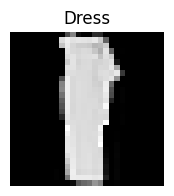

In [18]:
# visualize on sample inside train_dataloader 
torch.manual_seed(42)
plt.figure(figsize=(2,2))
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap='gray')
plt.title(class_names[label])
plt.axis('off')
plt.show()

In [19]:
# Create a flatten layer
flatten_model = nn.Flatten() # all nn modules function as a model (can do a forward pass)

# Get a single sample
x = train_features_batch[0]

# Flatten the sample
output = flatten_model(x) # perform forward pass

# Print out what happened
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")

# Try uncommenting below and see what happens
#print(x)
#print(output)

Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height*width]


### Building Model0

In [20]:
class FashionMNISTModelV0(nn.Module): 
    def __init__(self, 
                 input_shape:int, 
                 hidden_unit:int, 
                 output_shape:int):
        super().__init__()
        
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # [1, 28, 28 ] -> '28*28' [1, 784]
            nn.Linear(in_features=input_shape, out_features=hidden_unit), 
            nn.Linear(in_features=hidden_unit, out_features=output_shape)
        )
    
    def forward(self, x): 
        return self.layer_stack(x)

In [21]:
# create instance 
model_0 = FashionMNISTModelV0(input_shape=784, 
                              hidden_unit=10, 
                              output_shape=len(class_names)).to('cpu')
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [22]:
# one example test 
# dummy_data = torch.rand([1,1,28,28])

In [23]:
# model_0(dummy_data)

In [24]:
# !pip install torchmetrics

In [25]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [26]:
### Accuracy, Loss and Optimizer functions 
from torchmetrics import Accuracy
# acc_fn = Accuracy(task='multiclass', num_classes=10).to('cpu')
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(), 
                            lr=0.1)

In [27]:
# timer function 
from timeit import default_timer as timer 

def print_train_time(start:float, end:float, device:torch.device =None):
    total_time = end - start 
    print(f"Train time on {device} is {total_time:.2f} seconds")
    return total_time

In [28]:
start_time = timer()
print(f"Hello World")
end_time = timer()
print_train_time(start=start_time, end=end_time, device='cpu')

Hello World
Train time on cpu is 0.00 seconds


0.00018602299996928195

### Training Loops on Batch 

In [29]:
# X, y = next(iter(train_dataloader))
# X.shape, y.shape

In [30]:
# len(train_dataloader.dataset)

In [31]:
# len(X)

In [32]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epochs (we'll keep this small for faster training times)
epochs = 3

# Create training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    ### Training
    train_loss = 0
    # Add a loop to loop through training batches
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train() 
        # 1. Forward pass
        y_pred = model_0(X)

        # 2. Calculate loss (per batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulatively add up the loss per epoch 

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Print out how many samples have been seen
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    # Divide total train loss by length of train dataloader (average loss per batch per epoch)
    train_loss /= len(train_dataloader)
    
    ### Testing
    # Setup variables for accumulatively adding up loss and accuracy 
    test_loss, test_acc = 0, 0 
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            # 1. Forward pass
            test_pred = model_0(X)
           
            # 2. Calculate loss (accumulatively)
            test_loss += loss_fn(test_pred, y) # accumulatively add up the loss per epoch

            # 3. Calculate accuracy (preds need to be same as y_true)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))
        
        # Calculations on test metrics need to happen inside torch.inference_mode()
        # Divide total test loss by length of test dataloader (per batch)
        test_loss /= len(test_dataloader)

        # Divide total accuracy by length of test dataloader (per batch)
        test_acc /= len(test_dataloader)

    ## Print out what's happening
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

# Calculate training time      
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu, 
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.59484 | Test loss: 0.51635, Test acc: 81.84%

Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.47946 | Test loss: 0.48138, Test acc: 83.18%

Epoch: 2
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.45703 | Test loss: 0.47773, Test acc: 83.50%

Train time on cpu is 27.75 seconds


In [55]:
# Make predictions 
torch.manual_seed(42)
def eval_model(model: torch.nn.Module, 
              data_loader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module, 
              accuracy_fn): 
    """ Returns a dictionary containing model, loss and accuracy"""
    test_loss, test_accuracy = 0,0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            pred = model(X)
            
            loss = loss_fn(pred, y)
            test_loss += loss 
            
            test_accuracy += accuracy_fn(y, pred.argmax(dim=1))
            
        test_loss /= len(data_loader)
        test_accuracy /= len(data_loader)
    
    return {"model_name": model.__class__.__name__, 
            "model_loss": test_loss.item(), 
            "model_acc": test_accuracy}

model_0_results = eval_model(model=model_0, 
          data_loader=test_dataloader, 
          loss_fn=loss_fn, 
          accuracy_fn=accuracy_fn)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4777321219444275,
 'model_acc': 83.49640575079871}

In [34]:
# Device agnostic code 
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### MODEL_1: BUILDING NON-LINEARITY MODEL 

In [35]:
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape:int, 
                 hidden_unit:int, 
                 output_shape:int):
        super().__init__()
        
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            
            # layer 1 
            nn.Linear(in_features=input_shape, out_features=hidden_unit), 
            nn.ReLU(),
            
            # layer 2
            nn.Linear(in_features=hidden_unit, out_features=hidden_unit),
            nn.ReLU(),
            
        )
    
    def forward(self, x:torch.Tensor):
        return self.layer_stack(x)

In [36]:
# instance of FashionMNISTModel1 
model_1 = FashionMNISTModelV1(input_shape= 784,
                              hidden_unit=10, 
                              output_shape=len(class_names)).to(device)
model_1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [37]:
# next(model_1.parameters()).device

In [38]:
# setup loss, optimizer and accuracy function 
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_1.parameters(), 
                             lr=0.1)

# accuracy_fn = Accuracy(task='multiclass', num_classes=10).to(device)
from helper_functions import accuracy_fn


In [39]:
# # Functionizing training and testing loop 
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) # Go from logits -> pred labels

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode(): 
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)
            
            # 1. Forward pass
            test_pred = model(X)
            
            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Go from logits -> pred labels
            )
        
        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")         
    

In [40]:
# Training and Testing Loop
torch.manual_seed(42)
from timeit import default_timer as timer 

train_start_time_on_gpu = timer()
epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"\n\nEpoch: {epoch+1}\n-------------")
    train_step(model=model_1, 
               data_loader=train_dataloader, 
               loss_fn=loss_fn, 
               optimizer=optimizer, 
               accuracy_fn=accuracy_fn, 
               device=device)
    
    test_step(model=model_1, 
               data_loader=test_dataloader, 
               loss_fn=loss_fn, 
               accuracy_fn=accuracy_fn, 
               device=device)

train_end_time_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_start_time_on_gpu, 
                                      end=train_end_time_on_gpu, 
                                      device=device)

  0%|          | 0/3 [00:00<?, ?it/s]



Epoch: 1
-------------
Train loss: 0.98248 | Train accuracy: 65.06%
Test loss: 0.76060 | Test accuracy: 72.80%



Epoch: 2
-------------
Train loss: 0.70366 | Train accuracy: 74.48%
Test loss: 0.71731 | Test accuracy: 73.67%



Epoch: 3
-------------
Train loss: 0.67375 | Train accuracy: 75.31%
Test loss: 0.69170 | Test accuracy: 74.81%

Train time on cuda is 30.81 seconds


In [41]:
# EVALUATION 
# Move values to device
torch.manual_seed(42)
def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               accuracy_fn, 
               device: torch.device = device):
    """Evaluates a given model on a given dataset.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.
        device (str, optional): Target device to compute on. Defaults to device.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to the target device
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        
        # Scale loss and acc
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 1 results with device-agnostic code 
model_1_results = eval_model(model=model_1, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn,
    device=device
)
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6917039752006531,
 'model_acc': 74.810303514377}

### Building Model 2 : Convolutional Neural Network 

In [42]:
# create a cnn model 
class FashionMNISTModelV2(nn.Module):
    """ Tiny VGG"""
    def __init__(self, input_shape:int, 
                 hidden_units:int, 
                 output_shape:int):
        super().__init__()
        
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels = hidden_units, 
                      kernel_size =(3,3), # 3 
                      padding = 1, 
                      stride = 1),
            nn.ReLU(), 
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels = hidden_units, 
                      kernel_size =(3,3), # 3 
                      padding = 1, 
                      stride = 1),
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels = hidden_units, 
                      kernel_size =(3,3), # 3 
                      padding = 1, 
                      stride = 1),
            nn.ReLU(), 
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels = hidden_units, 
                      kernel_size =(3,3), # 3 
                      padding = 1, 
                      stride = 1),
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.classifier= nn.Sequential(
            nn.Flatten(), 
            nn.Linear(in_features=hidden_units*7*7, 
                      out_features = output_shape),
            nn.ReLU()
        )
        
    def forward(self, x:torch.Tensor):
        x = self.conv_block_1(x)
        # print(f"shape of conv_block_1: {x.shape}")
        x = self.conv_block_2(x)
        # print(f"shape of conv_block_2: {x.shape}")
        x = self.classifier(x)
        # print(f"shape of classifier block: {x.shape}")
        return x
            

In [43]:
# instances of class ModelV2
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1, 
    hidden_units=10, 
    output_shape=len(class_names)).to(device)
model_2

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
    (2): ReLU()
  )
)

In [44]:
# random_image_tensor = torch.randn(size=(1,28,28))
# random_image_tensor.shape

In [45]:
# random_image_tensor = random_image_tensor.unsqueeze(0)
# random_image_tensor = random_image_tensor.to(device)

In [46]:
# random_image_tensor.shape

In [47]:
# 10*7*7

In [48]:
# model_2(random_image_tensor.unsqueeze(0).to(device))

In [49]:
# Loss and Optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), 
                             lr=0.1)
from helper_functions import accuracy_fn

In [50]:
torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Train and test model 
epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader, 
        model=model_2, 
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 1.18936 | Train accuracy: 57.70%
Test loss: 0.99530 | Test accuracy: 64.74%

Epoch: 1
---------
Train loss: 0.96380 | Train accuracy: 65.40%
Test loss: 0.94574 | Test accuracy: 65.91%

Epoch: 2
---------
Train loss: 0.89963 | Train accuracy: 67.54%
Test loss: 0.78579 | Test accuracy: 71.88%

Train time on cuda is 36.06 seconds


In [51]:
# Evaluation 
model_2_results = eval_model(data_loader=test_dataloader, 
                            model=model_2, 
                            loss_fn=loss_fn, 
                            accuracy_fn=accuracy_fn)
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.7857866287231445,
 'model_acc': 71.875}

In [56]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results, model_1_results, model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.477732,83.496406
1,FashionMNISTModelV1,0.691704,74.810304
2,FashionMNISTModelV2,0.785787,71.875000


Text(0, 0.5, 'model')

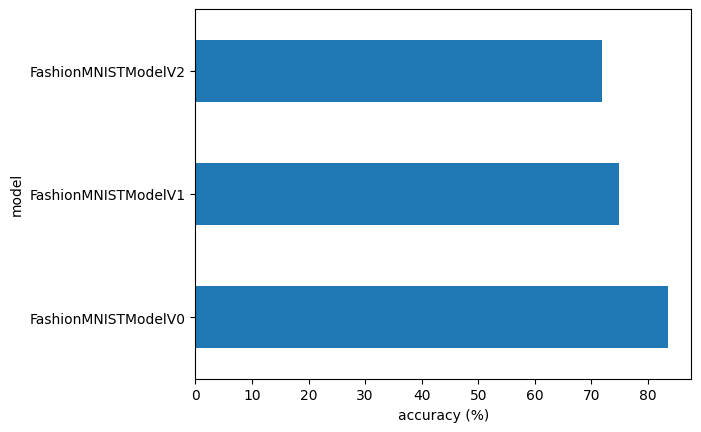

In [57]:
# Visualize our model results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model")